# Analisis Pengaruh Teknik Preprocessing terhadap Klasifikasi Ginjal Normal dan Batu Ginjal Menggunakan Fitur Gray Level Co-occurrence Matrix (GLCM) serta Perbandingan Algoritma Support Vector Machine (SVM), Random Forest, dan K-Nearest Neighbor (KNN)
## Percobaan 2 — Preprocessing: Grayscale + Resize + Median Filter + Histogram Equalization (4 Preprocessing)
### Nama Anggota
- Muhammad Andika Azkiya : F1D02410076
- Gusti Ayu Marsha Widyaswari : F1D02410007
- Ahmad Yadan Ulya Munaji : F1D02410100
- Revano Januar Adiguna Prawira : F1D02410146

In [19]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [20]:
def resize_image(image, target_size=(256, 256)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Assets'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (250, 250))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 200
Labels: ['Normal' 'kidneyStone']


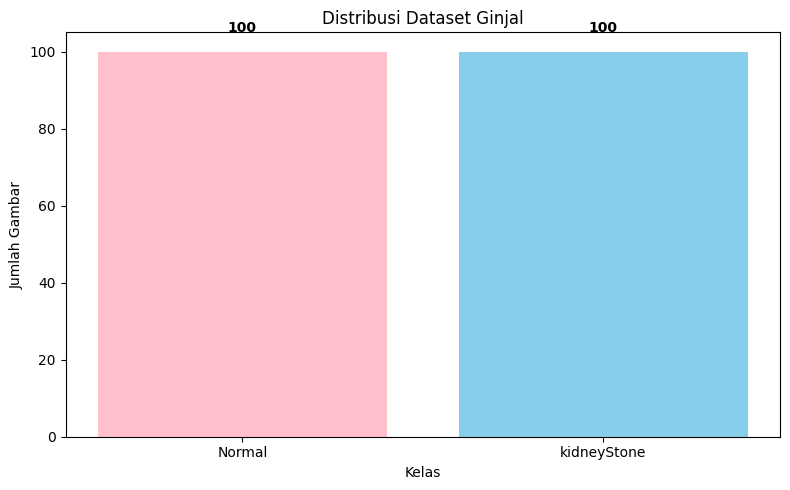

In [55]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['pink', 'skyblue'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Ginjal')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

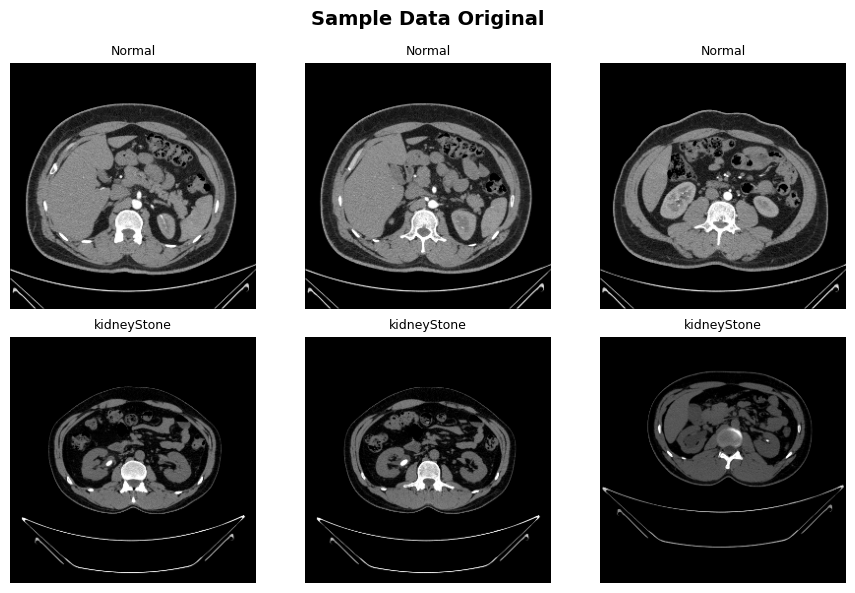

In [22]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

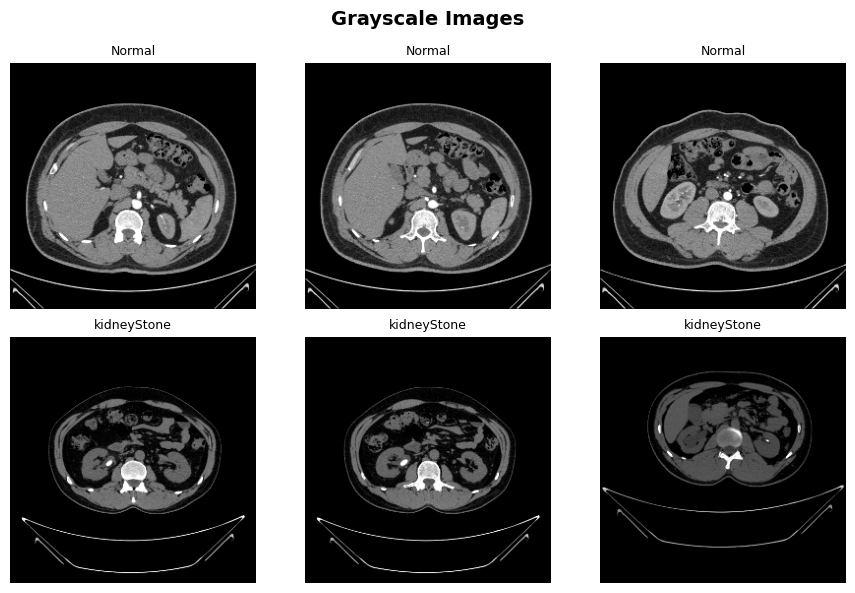

In [23]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names, 'Grayscale Images')

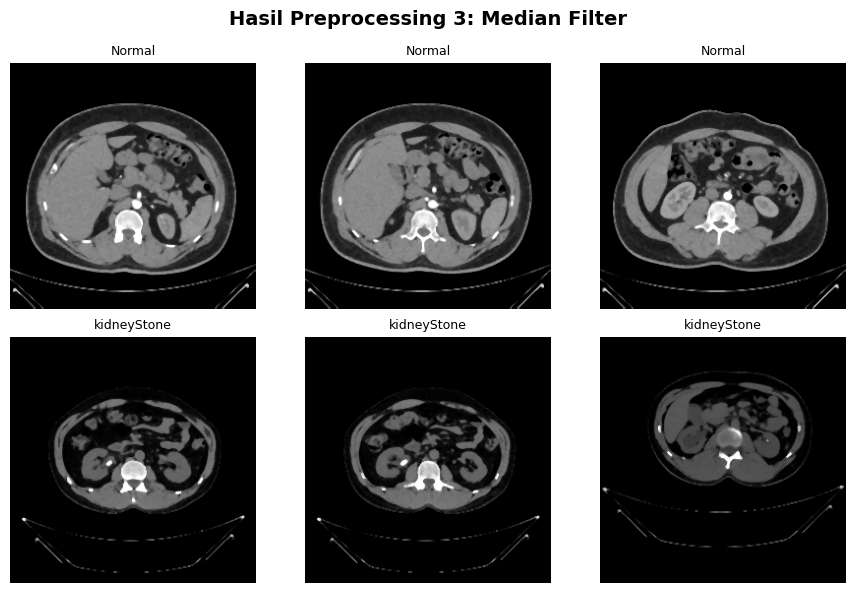

In [38]:
# Fungsi Median Filter
def hitung_median(image):
    return np.median(image)

def median_filter(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = hitung_median(window)
    return result.astype(np.uint8)

# Menerapkan Median Filter
img_median = []
for img in img_grey:
    filtered = median_filter(img, kernel_size=3)
    img_median.append(filtered)
img_median = np.array(img_median)

show_sample_images(img_median, labels, class_names, 'Hasil Preprocessing 3: Median Filter')

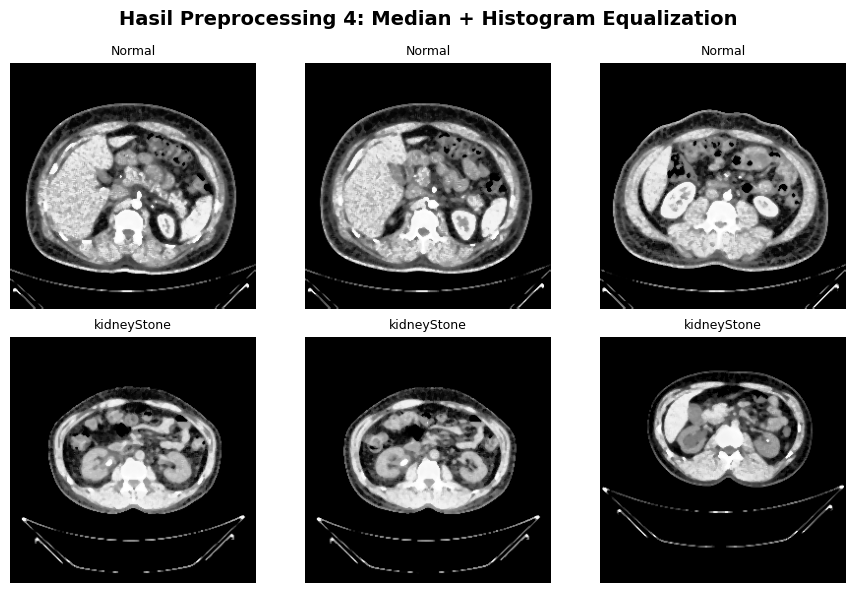

In [39]:
# Fungsi Histogram Equalization
def histogram_equalization(image):
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf[image]

# Menerapkan Histogram Equalization pada hasil median filter
dataPreprocessed = []
for img in img_median:
    equalized = histogram_equalization(img)
    dataPreprocessed.append(equalized)
dataPreprocessed = np.array(dataPreprocessed)

show_sample_images(dataPreprocessed, labels, class_names, 'Hasil Preprocessing 4: Median + Histogram Equalization')

In [40]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [41]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 200 images


In [42]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


In [43]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1.jpg,Normal,392.168900,790.976500,563.732337,766.201932,0.621165,0.566642,0.613055,0.566582,...,0.225624,0.222391,0.478951,0.471038,0.474999,0.471583,0.971793,0.943193,0.959453,0.944973
1,10.jpg,Normal,395.499036,793.460364,552.034586,746.875986,0.620822,0.570202,0.615056,0.569620,...,0.228984,0.225676,0.482490,0.474493,0.478522,0.475054,0.971469,0.942846,0.960176,0.946202
2,100.jpg,Normal,424.852353,850.685989,602.840209,778.566797,0.647642,0.595746,0.634603,0.595311,...,0.260892,0.257446,0.514945,0.506941,0.510776,0.507391,0.968319,0.936673,0.955045,0.942042
3,11.jpg,Normal,397.982120,800.546040,560.475855,754.405203,0.620770,0.570450,0.616750,0.570946,...,0.229203,0.225906,0.482758,0.474781,0.478752,0.475296,0.971256,0.942269,0.959521,0.945596
4,12.jpg,Normal,395.817799,801.044806,564.421767,756.879486,0.623136,0.569684,0.615680,0.571344,...,0.229519,0.226301,0.483082,0.475160,0.479081,0.475711,0.971430,0.942268,0.959260,0.945451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,95.jpg,kidneyStone,253.261590,493.395719,380.049189,508.258706,0.804028,0.768032,0.791413,0.767251,...,0.513672,0.508911,0.722564,0.712625,0.716709,0.713380,0.973120,0.947789,0.959663,0.946216
196,96.jpg,kidneyStone,253.879711,493.042080,380.539663,508.966759,0.804947,0.768601,0.793014,0.770022,...,0.515573,0.510814,0.723729,0.713957,0.718034,0.714712,0.972941,0.947608,0.959442,0.945916
197,97.jpg,kidneyStone,254.328803,491.224529,381.416064,512.907340,0.805049,0.768981,0.793116,0.768964,...,0.515048,0.510059,0.723349,0.713606,0.717669,0.714184,0.972886,0.947787,0.959337,0.945483
198,98.jpg,kidneyStone,254.968932,494.871341,382.626056,514.633409,0.805780,0.769215,0.793438,0.770073,...,0.515468,0.510617,0.723482,0.713610,0.717961,0.714574,0.972795,0.947356,0.959174,0.945254


Fitur sebelum seleksi: 28
Fitur setelah seleksi: 9
Fitur terpilih: ['Contrast0', 'Contrast45', 'Contrast135', 'Homogeneity0', 'Dissimilarity0', 'Entropy0', 'Correlation0', 'Correlation45', 'Correlation135']


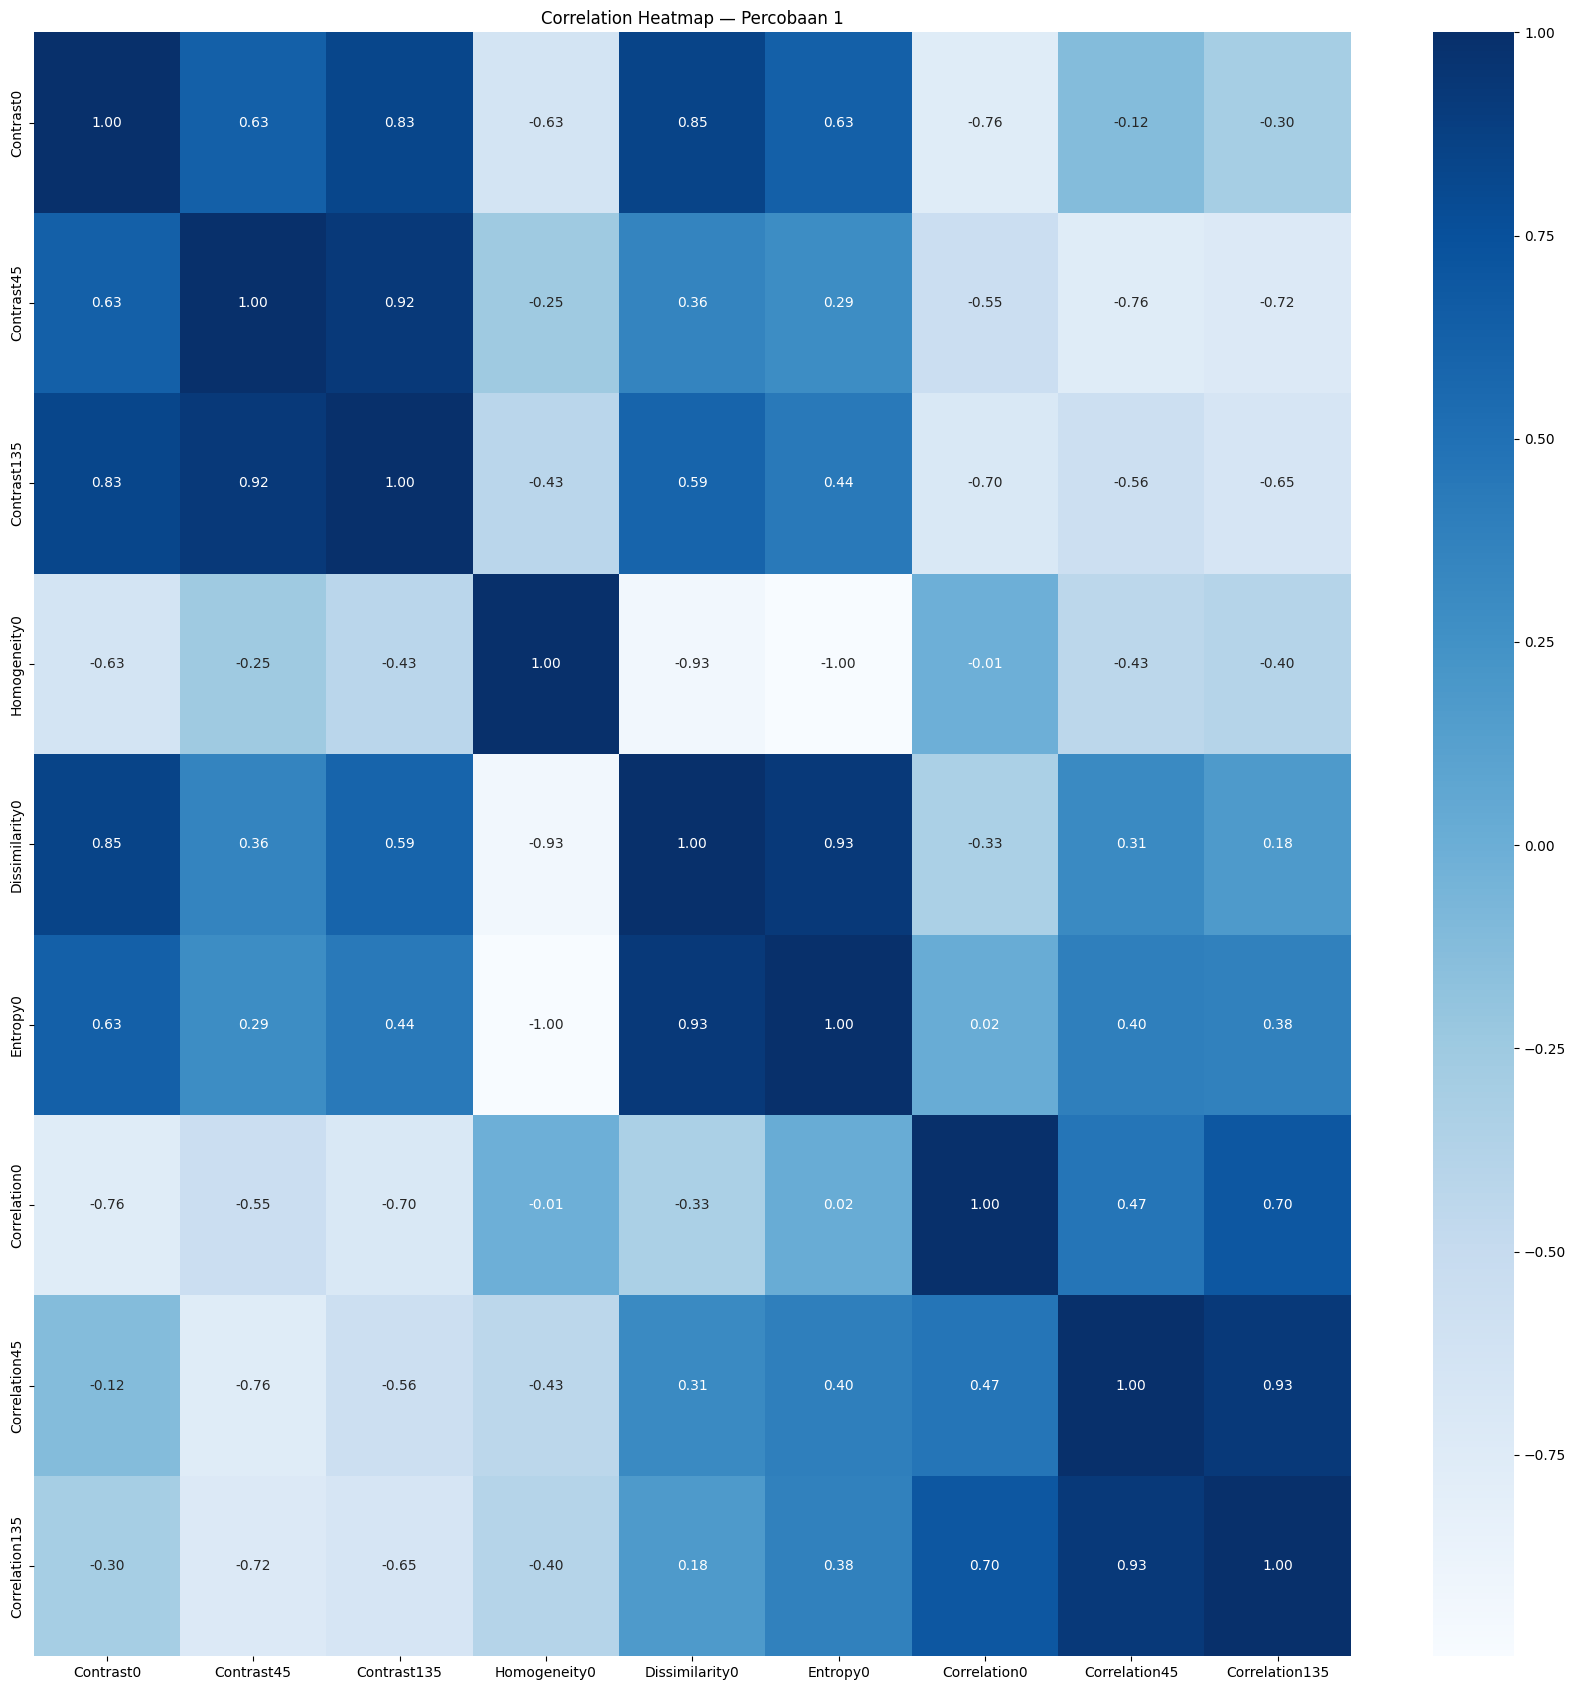

In [45]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Percobaan 1')
plt.tight_layout()
plt.show()

In [47]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.4, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (120, 9)
Testing set: (80, 9)


In [48]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [49]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [50]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        60
 kidneyStone       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        40
 kidneyStone       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Accuracy: 1.0


In [51]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        60
 kidneyStone       1.00      0.98      0.99        60

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120

Accuracy: 0.9916666666666667

------Testing Set------
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.96        40
 kidneyStone       1.00      0.93      0.96        40

    accuracy                           0.96        80
   macro avg       0.97      0.96      0.96        80
weighted avg       0.97      0.96      0.96        80

Accuracy: 0.9625


In [52]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        60
 kidneyStone       1.00      0.98      0.99        60

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120

Accuracy: 0.9916666666666667

------Testing Set------
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.96        40
 kidneyStone       1.00      0.93      0.96        40

    accuracy                           0.96        80
   macro avg       0.97      0.96      0.96        80
weighted avg       0.97      0.96      0.96        80

Accuracy: 0.9625


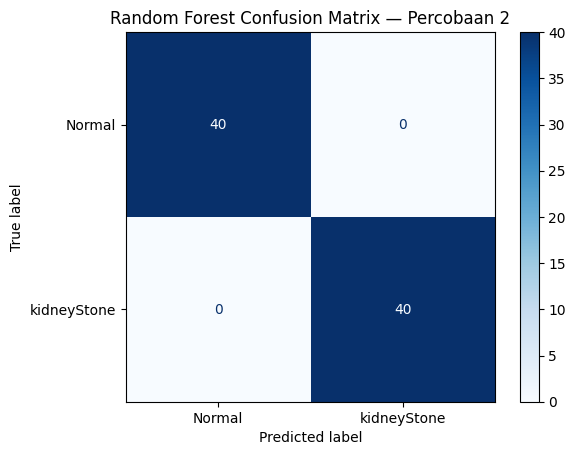

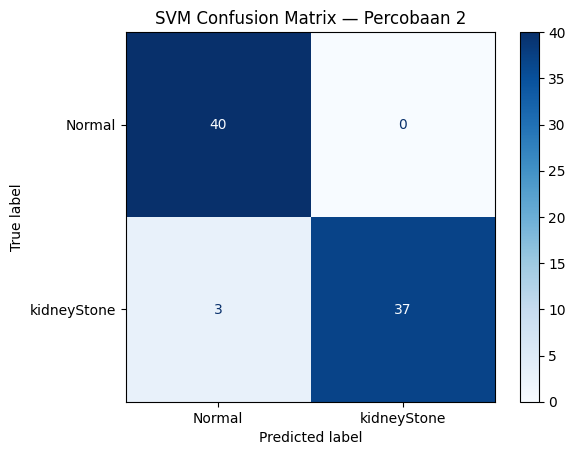

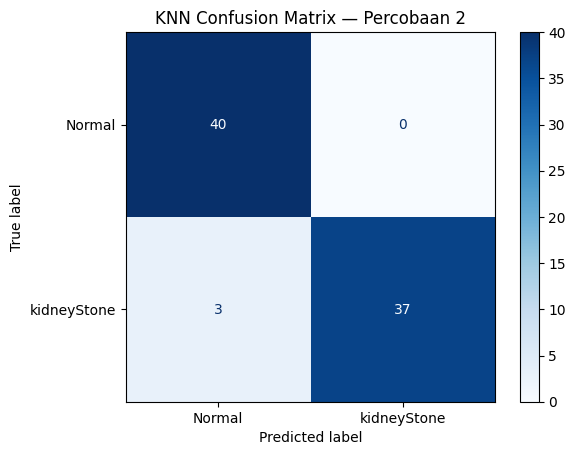

In [56]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Percobaan 2')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Percobaan 2')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Percobaan 2')

In [54]:
print('=== RINGKASAN HASIL PERCOBAAN 2 ===')
print(f'Preprocessing: Resize (256x256) + Grayscale + Median Filter + Histogram Equalization')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL PERCOBAAN 2 ===
Preprocessing: Resize (256x256) + Grayscale + Median Filter + Histogram Equalization
Jumlah Fitur Setelah Seleksi: 9

Akurasi Testing Set:
  Random Forest : 1.0000
  SVM           : 0.9625
  KNN           : 0.9625
